<a href="https://colab.research.google.com/github/Lakshaya7/Ecommerce-rfm-segmentation/blob/main/Customer_Segmentation_RFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
# The official UCI repository link for the Online Retail dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

print("Downloading and loading data... This might take 1-2 minutes because it's a large Excel file.")
df = pd.read_excel(url)

print("Data loaded successfully!")

# Display the first 5 rows
df.head()

Data loaded successfully!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
# Number of rows are there in the dataset
print(f"Rows before cleaning : {len(df)}")

Rows before cleaning : 541909


In [7]:
# Drop rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [9]:
# Keep only rows where Quantity > 0
df = df[df['Quantity'] > 0]
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [10]:
# Create a new column called 'TotalAmount'
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [11]:
print(f"Rows after cleaning: {len(df)}")

# Display the updated structure and the first few rows
df.info()
display(df.head())

Rows after cleaning: 397924
<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  object        
 8   TotalAmount  397924 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [12]:
import datetime as dt

# Find the most recent transaction date in the dataset
latest_date = df['InvoiceDate'].max()

# Create our 'snapshot' date by adding 1 day
snapshot_date = latest_date + dt.timedelta(days=1)

print(f"Our reference date for Recency is: {snapshot_date}")

Our reference date for Recency is: 2011-12-10 12:50:00


In [17]:
# Group by customer and calculate R, F, and M
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})
# Display the first 5 customers
print(rfm.head())

            InvoiceDate  InvoiceNo  TotalAmount
CustomerID                                     
12346.0             326          1     77183.60
12347.0               2          7      4310.00
12348.0              75          4      1797.24
12349.0              19          1      1757.55
12350.0             310          1       334.40


In [18]:
# Rename columns for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)


display(rfm.head())

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [19]:
# Create labels for our quartiles
r_labels = range(4, 0, -1) # 4, 3, 2, 1 (Lower recency = higher score)
f_labels = range(1, 5)     # 1, 2, 3, 4 (Higher frequency = higher score)
m_labels = range(1, 5)     # 1, 2, 3, 4 (Higher monetary = higher score)

# Assign scores using pd.qcut
rfm['R'] = pd.qcut(rfm['Recency'], q=4, labels=r_labels)

# We use rank(method='first') on frequency to handle edge cases where many customers have exactly 1 purchase
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=f_labels)
rfm['M'] = pd.qcut(rfm['Monetary'], q=4, labels=m_labels)

In [20]:
# Ensure our scores are treated as integers for math
rfm['R'] = rfm['R'].astype(int)
rfm['F'] = rfm['F'].astype(int)
rfm['M'] = rfm['M'].astype(int)

# Sum the scores to get an overall RFM Score
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)

# Look at the new columns
display(rfm.head())

,Recency,Frequency,Monetary,R,F,M,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,6
12347.0,2,7,4310.00,4,4,4,12
12348.0,75,4,1797.24,2,3,4,9
12349.0,19,1,1757.55,3,1,4,8
12350.0,310,1,334.40,1,1,2,4


In [21]:
# Define the logic for segmenting
def assign_segment(score):
  if score >= 10:
    return 'Champions'
  elif score >= 8:
    return 'Loyal Customers'
  elif score >= 6:
    return 'Potential Loyalists'
  elif score >= 4:
    return 'At Risk'
  else:
    return 'Lost'

# Apply the logic to create the 'RFM_Segment' column
rfm['RFM_Segment'] = rfm['RFM_Score'].apply(assign_segment)

segment_counts = rfm['RFM_Segment'].value_counts()

# Display the counts of each segment
print(segment_counts)

RFM_Segment
Champions              1268
At Risk                 988
Potential Loyalists     938
Loyal Customers         843
Lost                    302
Name: count, dtype: int64


In [23]:
# 1. Sum the scores to get an overall RFM Score
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)

# 2. Define the logic for segmenting
def assign_segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

# 3. Apply the function to create the missing column
rfm['Customer_Segment'] = rfm['RFM_Score'].apply(assign_segment)

# Verify it worked
print(rfm.columns)

Index(['Recency', 'Frequency', 'Monetary', 'R', 'F', 'M', 'RFM_Score',
       'RFM_Segment', 'Customer_Segment'],
      dtype='object')


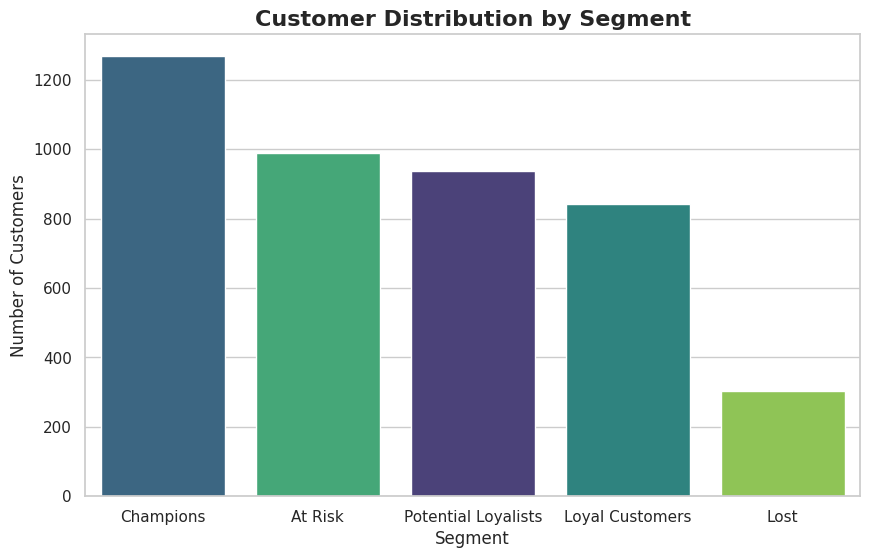

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

# 1. Bar Chart: Size of each segment
plt.figure(figsize=(10, 6))
sns.countplot(
    data=rfm,
    x='Customer_Segment',
    order=rfm['Customer_Segment'].value_counts().index,
    hue='Customer_Segment',
    palette='viridis',
    legend=False
)
plt.title('Customer Distribution by Segment', fontsize=16, fontweight='bold')
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

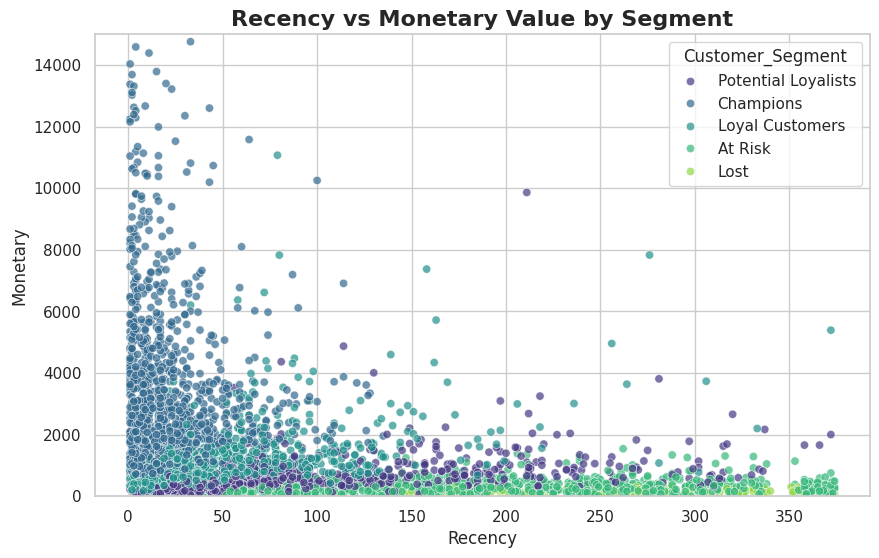

In [25]:
# 2. Scatter Plot: Recency vs. Monetary (capped at £15k for readability)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Customer_Segment',
    palette='viridis',
    alpha=0.7
)
plt.title('Recency vs Monetary Value by Segment', fontsize=16, fontweight='bold')
plt.ylim(0, 15000) # Capping outliers so the main clusters are visible
plt.show()

Champions: These are our most valuable customers. Action: Give them early access to new products and invite them to loyalty programs to maintain engagement.

Potential Loyalists: They bought recently and frequently, but haven't spent top dollar yet. Action: Recommend cross-sells or bundle deals to increase their average order value.

At Risk: They used to spend a lot and buy often, but haven't returned in a long time. Action: Send personalized win-back emails with heavy discount codes.